In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [10]:
ticker = "TSLA"

df = yf.download(ticker, start="2018-01-01", end="2025-01-01")

print(df.head())

/tmp/ipykernel_11400/2049474322.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2018-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open     Volume
Ticker           TSLA       TSLA       TSLA       TSLA       TSLA
Date                                                             
2018-01-02  21.368668  21.474001  20.733334  20.799999   65283000
2018-01-03  21.150000  21.683332  21.036667  21.400000   67822500
2018-01-04  20.974667  21.236668  20.378668  20.858000  149194500
2018-01-05  21.105333  21.149332  20.799999  21.108000   68868000
2018-01-08  22.427334  22.468000  21.033333  21.066668  147891000


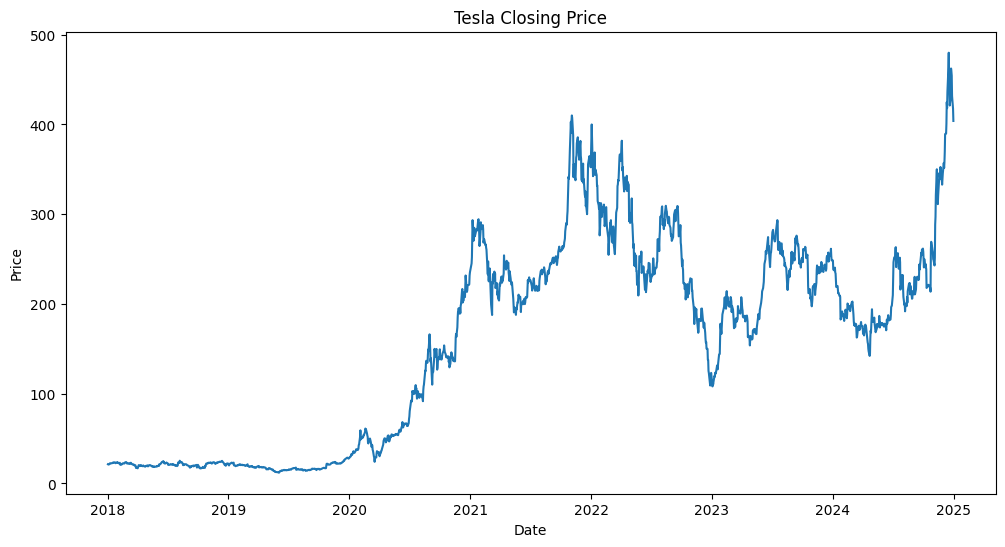

In [11]:
data = df[['Close']]

plt.figure(figsize=(12,6))
plt.plot(data)
plt.title("Tesla Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [13]:
scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(data)

In [14]:
def create_dataset(dataset, time_step=60):

    X = []
    y = []

    for i in range(time_step, len(dataset)):
        X.append(dataset[i-time_step:i,0])
        y.append(dataset[i,0])

    return np.array(X), np.array(y)

time_step = 60

X, y = create_dataset(scaled_data, time_step)

In [15]:
train_size = int(len(X)*0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [16]:
X_train = X_train.reshape(X_train.shape[0],
                          X_train.shape[1],
                          1)

X_test = X_test.reshape(X_test.shape[0],
                        X_test.shape[1],
                        1)

In [17]:
model = Sequential()

model.add(LSTM(64,
               return_sequences=True,
               input_shape=(60,1)))

model.add(Dropout(0.2))

model.add(LSTM(64))

model.add(Dropout(0.2))

model.add(Dense(25))

model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,571 (201.45 KB)

 Trainable params: 51,571 (201.45 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test,y_test)
)

Epoch 1/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - loss: 0.0105 - val_loss: 0.0026
Epoch 2/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 0.0021 - val_loss: 0.0024
Epoch 3/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - loss: 0.0022 - val_loss: 0.0023
Epoch 4/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - loss: 0.0020 - val_loss: 0.0020
Epoch 5/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 0.0019 - val_loss: 0.0020
Epoch 6/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - loss: 0.0016 - val_loss: 0.0021
Epoch 7/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 0.0016 - val_loss: 0.0016
Epoch 8/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - loss: 0.0014 - val_loss: 0.0017
Epoch 9/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 0.0014 - val_loss: 0.0014
Epoch 10/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 0.0014 - val_loss: 0.0015
Epoch 11/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 0.0012 - val_loss: 0.0014
Epoch 12/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - loss: 0.0

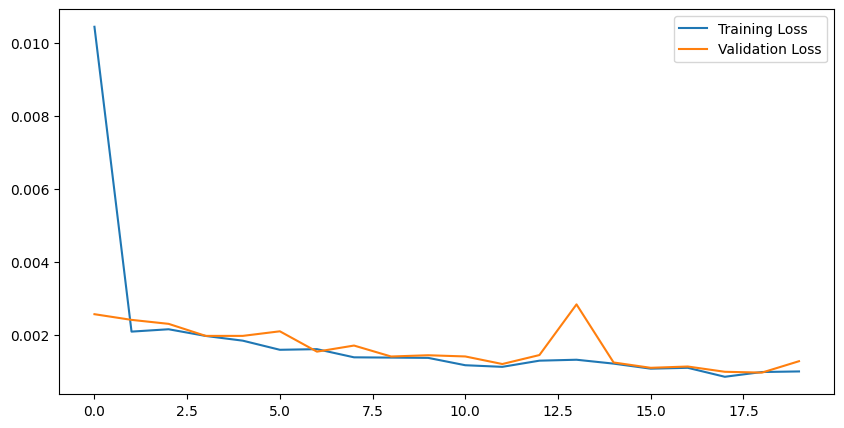

In [19]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')

plt.legend()

plt.show()

In [20]:
predictions = model.predict(X_test)

predictions = scaler.inverse_transform(predictions)

actual = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step


In [21]:
rmse = np.sqrt(
    mean_squared_error(actual,predictions)
)

print("RMSE:",rmse)

RMSE: 16.800216444487113


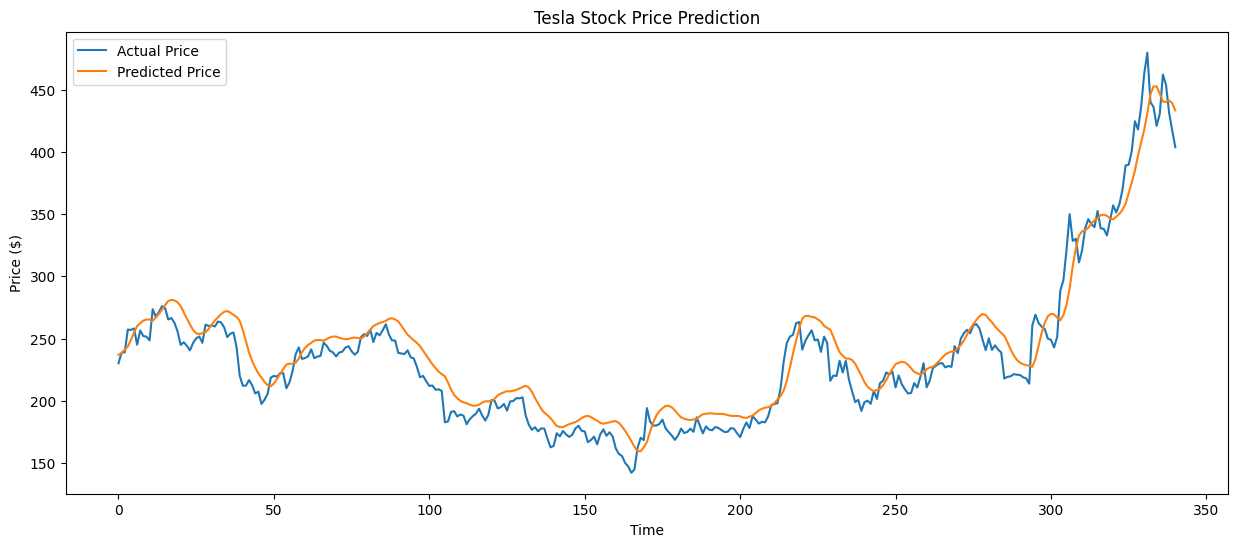

In [22]:
plt.figure(figsize=(15,6))

plt.plot(actual,label='Actual Price')

plt.plot(predictions,label='Predicted Price')

plt.title("Tesla Stock Price Prediction")

plt.xlabel("Time")

plt.ylabel("Price ($)")

plt.legend()

plt.show()

In [23]:
last_60_days = scaled_data[-60:]

X_future = np.array(last_60_days)

X_future = X_future.reshape(1,60,1)

future_price = model.predict(X_future)

future_price = scaler.inverse_transform(future_price)

print("Next Day Predicted Tesla Price:",future_price[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Next Day Predicted Tesla Price: 424.59744
